In [318]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from shared.model_params import shift, lag_size, n_clusters
import sqlite3

In [319]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit, LeaveOneGroupOut, GroupKFold
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [320]:
import torch
import torch.nn as nn

In [321]:
class DataLoader:
    def __init__(self, countries, max_count = (0, 5), shift_size = 4, lag_size = 6, logging = True):
        self.countries = countries
        self.max_count = max_count
        self.shift_size = shift_size
        self.lag_size = lag_size
        self.logging = logging
        self.conn = sqlite3.connect("dataset.db")

    def get_datasets(self):
        X = pd.DataFrame()
        y = pd.DataFrame()
        for country in self.countries:
            for ind in range(*self.max_count):
                data = pd.read_sql(f"SELECT * FROM runs_stats WHERE game_ind = {ind} AND country = '{country}'", self.conn)
                data["war_status"] = data["war_status"].astype(int)
                X_new, y_new = self._split_Xy(data)
                X = pd.concat([X, X_new], axis=0)
                y = pd.concat([y, y_new], axis=0)
        return X, y

    
    def _split_Xy(self, data):
        X = data[:-self.shift_size].reset_index(drop=True)
        y = self._prepare_target(data["gdp"][self.shift_size:].reset_index(drop=True).bfill().ffill())
        return X, y

    
    def _prepare_target(self, y):
        return np.log1p(y)
    
    def train_test_split(self, X, y, test_pairs):
        """
        1) - X_train
        2) - y_train
        3) - X_test
        4) - y_test
        """
        X_copy = X.copy()
        y_copy = y.copy()
        X_test = pd.DataFrame()
        y_test = pd.DataFrame()
        for country, ind in test_pairs:
            mask = (X_copy["country"] == country) & (X_copy["game_ind"] == ind)
            X_ = X_copy[mask]
            y_ = y_copy[mask]

            X_test = pd.concat([X_test, X_], axis = 0)
            y_test = pd.concat([y_test, y_], axis = 0)
            X_copy = X_copy[~mask]
            y_copy = y_copy[~mask]

        return (
            X_copy.reset_index(drop=True), 
            y_copy.reset_index(drop=True), 
            X_test.reset_index(drop=True), 
            y_test.reset_index(drop=True)
        )
    
    
class PrepareColNames:
    def __init__(self, lag_size):
        self.lag_size = lag_size

    @staticmethod
    def _generate_period_names(data):
        bins = [0, 1850, 1862, 1873, 1885, 1895, 1906, np.inf]
        labels = [
            '1836-1850',
            '1851-1862', 
            '1863-1873', 
            '1874-1885', 
            '1886-1895', 
            '1896-1906', 
            '1907+'
        ]
        year = pd.to_datetime(data["date"]).dt.year
        name = data["flag_name"].str.split("_").str[0]
        periods = pd.cut(year, bins=bins, labels=labels)
        return name + " (" + periods.astype(str) + ")"

    
    def add_name(self, data):
        data["name"] = self._generate_period_names(data)
        return data

    def add_new_cols(self, arr):
        res = []
        for col in arr:
            for i in range(1, self.lag_size + 1):
                res.append(f"{col}_log_diff_{i}")
            res.append(f"{col}_rolling_mean_3")
            res.append(f"{col}_rolling_std_5")
        return res
    
    def cluster_cols(self, num):
        res = []
        for i in range(num):
            res.append(f"dist_to_c{i+1}")
        return res

In [322]:
class DataProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, num_cols, important_cols, lag_size):
        self.num_cols = num_cols
        self.important_cols = important_cols
        self.lag_size = lag_size

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        new_cols = {}
        X["gdp"] = X["gdp"].bfill().ffill()
        X["gdp"] = np.log1p(X["gdp"])
        X["tax_progressivity"] = X["rich_tax"] - X["poor_tax"]
        X["innovation_total"] = X["prom_innov"] + X["comm_innov"]
        for col in self.num_cols:
            X[col] = X[col].bfill().ffill().astype(float)
        for col in self.important_cols:
            for i in range(1, self.lag_size + 1):
                new_cols[f"{col}_log_diff_{i}"] = np.log1p(X[col]).diff(i)
            new_cols[f"{col}_rolling_mean_3"] = X[col].rolling(3).mean()
            new_cols[f"{col}_rolling_std_5"] = X[col].rolling(5).std()
        X = pd.concat([X, pd.DataFrame(new_cols, index=X.index)], axis=1)
        return X.ffill().bfill()
     

class DataSelector(BaseEstimator, TransformerMixin):
    def __init__(self, all_cols):
        self.all_cols = all_cols
    
    def fit(self, X, y = None):
        return self
    
    def transform(self, X):
        return X[self.all_cols]
    

class ClusterPredictor(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=5, features_for_clustering=None):
        self.n_clusters = n_clusters
        self.features_for_clustering = features_for_clustering
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)

    def fit(self, X, y=None):
        x_subset = X[self.features_for_clustering]
        x_scaled = self.scaler.fit_transform(x_subset)
        self.kmeans.fit(x_scaled)
        return self

    def transform(self, X):
        X = X.copy()
        x_subset = X[self.features_for_clustering]
        x_scaled = self.scaler.transform(x_subset)
        cluster_distances = self.kmeans.transform(x_scaled)
        df_clust = pd.DataFrame(
            cluster_distances, 
            columns=[f"dist_to_c{i + 1}" for i in range(self.n_clusters)],
            index=X.index
        )
        X["cluster"] = self.kmeans.predict(x_scaled)
        X["cluster"] = X["cluster"].astype(str)

        X = pd.concat([X, df_clust], axis=1)
        
        return X

    def get_scaler(self):
        return self.scaler


class Model(TransformerMixin, RegressorMixin, BaseEstimator):
    def __init__(self, lr, hidden_size, n_epochs, verbose):
        self.hidden_size = hidden_size
        self.n_epochs = n_epochs
        self.verbose = verbose
        self.loss = nn.MSELoss()
        self.lr = lr

    def fit(self, X, y = None):
        X_numeric = X.select_dtypes(include=['number'])
        input_size = X_numeric.shape[1]
        
        self.model = nn.Sequential(
            nn.Linear(input_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        X_tensor = torch.tensor(X_numeric.values, dtype=torch.float32)
        y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

        for epoch in range(self.n_epochs):
            self.optimizer.zero_grad()

            y_pred = self.model(X_tensor)
            error = self.loss(y_pred, y_tensor.view(-1, 1))
            error.backward()

            self.optimizer.step()

            if epoch % self.verbose == 0:
                mae = np.mean(np.abs(y_pred.detach().numpy() - y.values))
                print(f"Epoch: {epoch}, loss: {mae}")

        self.is_fitted_ = True
        return self

    def transform(self, X):
        return X

    def predict(self, X):
        X_numeric = X.select_dtypes(include=['number'])
        self.model.eval()

        with torch.no_grad():
            X_tensor = torch.tensor(X_numeric.values, dtype=torch.float32)
            result = self.model(X_tensor)
        
        return result.numpy()

In [323]:
loader = DataLoader(["ENG", "RUS", "AUS", "CHI", "BEL", "PRU", "SWE", "FRA", "ETH", "TUR", "SIC", "MEX", "AFG", "PER", "POR", "USA", "NET"], (1, 6), shift_size=shift, lag_size=lag_size, logging=False)
namer = PrepareColNames(lag_size = lag_size)

In [324]:
cat_cols = ["most_popular_party", "war_status", "cluster"]
num_cols = ["money_activity", "subside_percent", "rentability", "diversification", "gdp_per_cap", "gdp_per_reg",\
             "country_savings", "bank_savings", "population_savings", "money_mass", "all_employemenent", "all_free_work_places", "fabric_worker_salary",\
             "capitalist_salary", "literacy", "military_budget", "naval_budget", "army_innov", "naval_innov", "country_size", "population_per_reg",\
             "rich_tax", "middle_tax", "poor_tax", "prom_innov", "comm_innov", "tax_progressivity", "innovation_total"]

important_cols = ["gdp", "poor_tax", "bank_savings", "population"]
im_cols = ["poor_tax", "bank_savings", "population"]
new_num_cols = namer.add_new_cols(im_cols)
deleted_cols = ["industrial_level", "subside_pct", "gold_income", "goverement"]
all_cols = cat_cols + num_cols + new_num_cols + namer.cluster_cols(3)
cluster_cols = ["money_activity", "rentability", "diversification", "literacy", "prom_innov", "comm_innov", "innovation_total", "tax_progressivity", "subside_percent", "fabric_worker_salary",\
                "capitalist_salary", "population_per_reg"]

In [325]:
X, y = loader.get_datasets()

C:\Users\User\AppData\Local\Temp\ipykernel_8528\4102240814.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  X = pd.concat([X, X_new], axis=0)
C:\Users\User\AppData\Local\Temp\ipykernel_8528\4102240814.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  y = pd.concat([y, y_new], axis=0)
C:\Users\User\AppData\Local\Temp\ipykernel_8528\4102240814.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer ex

In [326]:
test_pairs = [("ENG", 1), ("NET", 2)]

In [327]:
X, y, X_test, y_test = loader.train_test_split(X, y, test_pairs)

In [ ]:
pipe = Pipeline([
    ("Data Prepare", DataProcessor(num_cols=num_cols, important_cols=important_cols, lag_size = lag_size)),
    ("Scaler", StandardScaler()),
    ("Clusterisation", ClusterPredictor(n_clusters=3, features_for_clustering=cluster_cols)),
    ("Data Select", DataSelector(all_cols=all_cols)),
    ("Model", Model(lr = 0.05, n_epochs = 1500, verbose=100, hidden_size=64))
])

In [329]:
pipe.fit(X, y)

C:\Users\User\AppData\Local\Temp\ipykernel_8528\3036056285.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.ffill().bfill()


Epoch: 0, loss: 16868.38377623534
Epoch: 100, loss: 7.365248875197943
Epoch: 200, loss: 7.3651743060620385
Epoch: 300, loss: 7.365076710906799
Epoch: 400, loss: 7.364958114427503
Epoch: 500, loss: 7.364819976937945
Epoch: 600, loss: 7.364663052809413
Epoch: 700, loss: 7.364487748098548
Epoch: 800, loss: 7.3642940888823825
Epoch: 900, loss: 7.3640820267321425
Epoch: 1000, loss: 7.363851310190733
Epoch: 1100, loss: 7.363601602119382
Epoch: 1200, loss: 7.363332464796479
Epoch: 1300, loss: 7.363043359917577
Epoch: 1400, loss: 7.362733693298872


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Data Prepare', ...), ('Clusterisation', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,num_cols,"['money_activity', 'subside_percent', ...]"
,important_cols,"['gdp', 'poor_tax', ...]"
,lag_size,12
,n_clusters,3
,features_for_clustering,"['money_activity', 'rentability', ...]"
,all_cols,"['most_popular_party', 'war_status', ...]"
,lr,0.05


In [330]:
np.expm1(y_test)

,gdp
0,11496.0
1,11908.0
2,12320.0
3,12258.0
4,12327.0
...,...
267,3969.0
268,4101.0
269,4337.0
270,4193.0


In [332]:
pred

array([[-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0.01654882],
       [-0

C:\Users\User\AppData\Local\Temp\ipykernel_8528\3036056285.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.ffill().bfill()


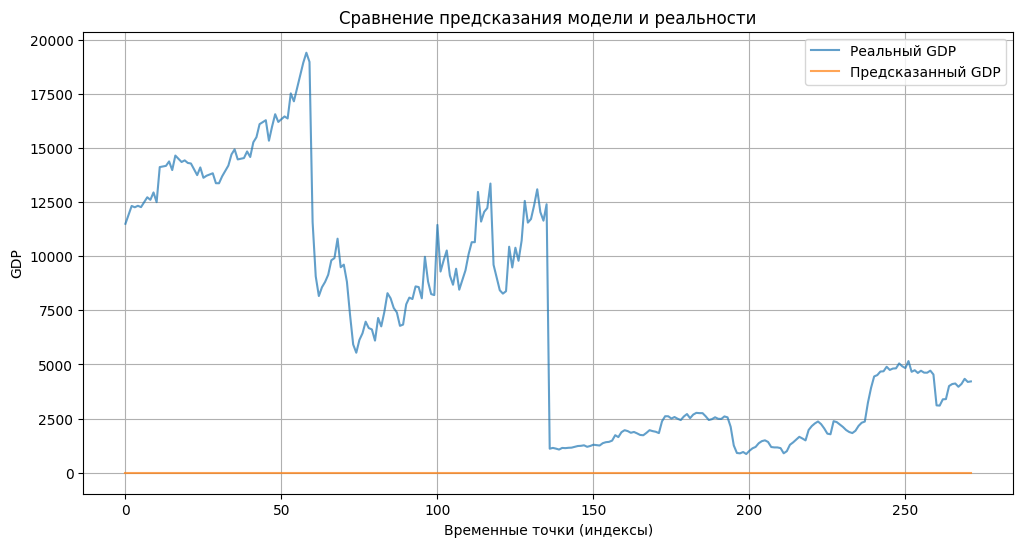

In [331]:
import matplotlib.pyplot as plt

pred = pipe.predict(X_test)

real_values = np.expm1(y_test)
pred_values = np.expm1(pred)

plt.figure(figsize=(12, 6))
plt.plot(real_values.values, label='Реальный GDP', alpha=0.7)
plt.plot(pred_values, label='Предсказанный GDP', alpha=0.7)

plt.title('Сравнение предсказания модели и реальности')
plt.xlabel('Временные точки (индексы)')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()